# Project 6 — Stacking, Blending, and Meta-Learning Ensembles

This advanced foundation notebook studies how to combine diverse models through hard voting, soft voting, probability averaging, blending, and stacking. The focus is on model diversity and leakage prevention.

## Theoretical background: stacking, blending, and meta-learning ensembles

Voting and stacking combine multiple models, but they do so differently. **Hard voting** uses the majority class predicted by base models. **Soft voting** averages predicted probabilities, so models with stronger confidence can influence the final decision. Soft voting can work well only when probability estimates are reasonably calibrated.

**Blending** trains base models on one part of the training data and trains a meta-learner on their predictions on a separate validation set. It is easy to understand, but it uses less data for fitting the base models. **Stacking** improves this idea by generating out-of-fold predictions: each training sample receives a prediction from a model that did not train on that sample. The meta-learner then learns how to combine these leakage-free predictions.

The success of stacking depends on **diversity**. If all base models make almost identical errors, the meta-learner has little new information to exploit. A weaker model can still be useful if it makes complementary errors. However, stacking can overfit on small datasets, especially if the meta-learner is too flexible.

This notebook studies whether ensembles truly correct errors made by individual models, or whether they only add complexity without meaningful gain.

## Problem statement

Given multiple candidate classifiers, build ensemble systems that combine their strengths while avoiding leakage.

## Dataset description and source

The Breast Cancer Wisconsin dataset is loaded directly from `sklearn.datasets.load_breast_cancer`. It is small enough for multiple base models and stacking experiments.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.base import clone

The Breast Cancer dataset is loaded directly from scikit-learn. The initial checks show the number of observations, feature columns, target labels, and whether the task is suitable for classification experiments.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
X = df.drop(columns="target")
y = df["target"]
print("Shape:", df.shape)
display(y.value_counts(normalize=True).rename("class_proportion").to_frame())
display(df.head())

Shape: (569, 31)


,class_proportion
1,0.627417
0,0.372583


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Analytical interpretation

The dataset is clean and compact, which makes it suitable for repeated experiments. The class proportions should be checked before interpreting accuracy because imbalance can make a naive classifier look better than it really is.

## EDA summary

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

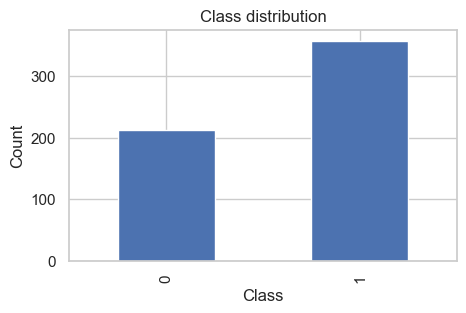

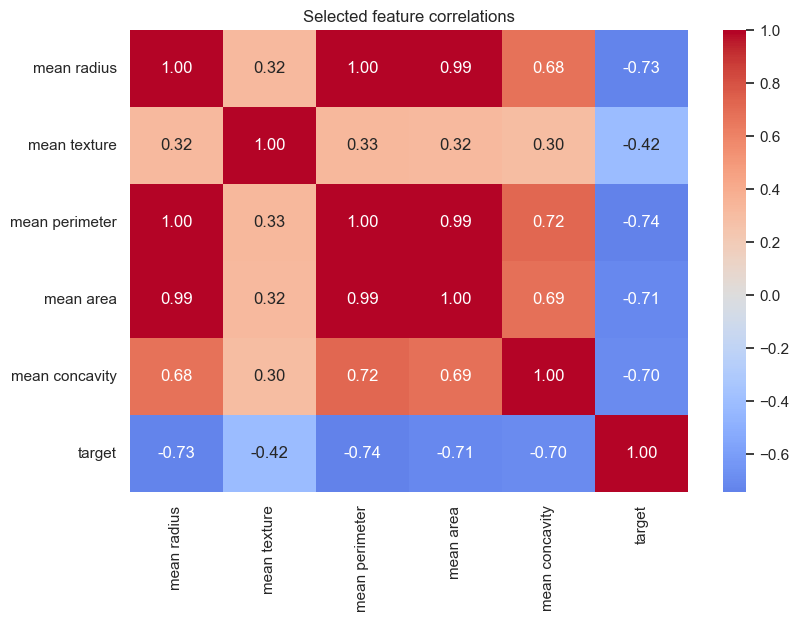

In [3]:
y.value_counts().sort_index().plot(kind="bar", figsize=(5,3), title="Class distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()
selected = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean concavity"]
plt.figure(figsize=(9,6))
sns.heatmap(df[selected + ["target"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Selected feature correlations")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

## Train/validation/test split

For blending, the training data is split into base-training and blending-validation sets. For stacking, out-of-fold predictions are used to reduce leakage.

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_base, X_blend, y_base, y_blend = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print("base train:", X_base.shape, "blend validation:", X_blend.shape, "test:", X_test.shape)

base train: (341, 30) blend validation: (114, 30) test: (114, 30)


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

This cell varies the decision threshold and records how the error trade-off changes. The purpose is to choose a threshold based on the objective, not to assume that 0.5 is always appropriate.

In [5]:
def binary_metrics(y_true, y_pred, y_score=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, y_score)
        out["PR_AUC"] = average_precision_score(y_true, y_score)
    return out

def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores
    return None

def evaluate_binary_model(name, model, X_train, y_train, X_val, y_val, threshold=0.5, fit=True):
    start = time.time()
    if fit:
        model.fit(X_train, y_train)
    runtime = time.time() - start
    val_score = get_positive_scores(model, X_val)
    if val_score is not None and hasattr(model, "predict_proba"):
        val_pred = (val_score >= threshold).astype(int)
    else:
        val_pred = model.predict(X_val)
    row = {"Model": name, "Threshold": threshold, "Runtime_sec": runtime}
    row.update(binary_metrics(y_val, val_pred, val_score))
    return row

## Base models

The base learners are intentionally diverse: linear, distance-based, margin-based, single tree, bagging-style, and boosting-style.

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [6]:
base_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
    "SVM RBF": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, max_depth=2, random_state=RANDOM_STATE),
}
rows=[]
for name, model in base_models.items():
    start=time.time(); model.fit(X_base, y_base); runtime=time.time()-start
    score = get_positive_scores(model, X_test)
    pred = model.predict(X_test)
    row={"Model": name, "runtime_sec": runtime}
    row.update(binary_metrics(y_test, pred, score))
    rows.append(row)
base_df=pd.DataFrame(rows).sort_values("F1", ascending=False)
display(base_df)

,Model,runtime_sec,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,KNN,0.000000,0.982456,0.972973,1.000000,0.986301,0.991733,0.993475
0,Logistic Regression,0.262360,0.982456,0.986111,0.986111,0.986111,0.995040,0.996880
2,SVM RBF,0.032848,0.973684,0.972603,0.986111,0.979310,0.994378,0.996585
4,Random Forest,0.198788,0.947368,0.958333,0.958333,0.958333,0.991733,0.995124
5,Gradient Boosting,0.783567,0.938596,0.945205,0.958333,0.951724,0.991071,0.994773
3,Decision Tree,0.015348,0.912281,0.969697,0.888889,0.927536,0.941964,0.959425


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Model diversity analysis

Ensembles help most when models make different errors. If all models fail on the same samples, voting or stacking may not improve much.

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

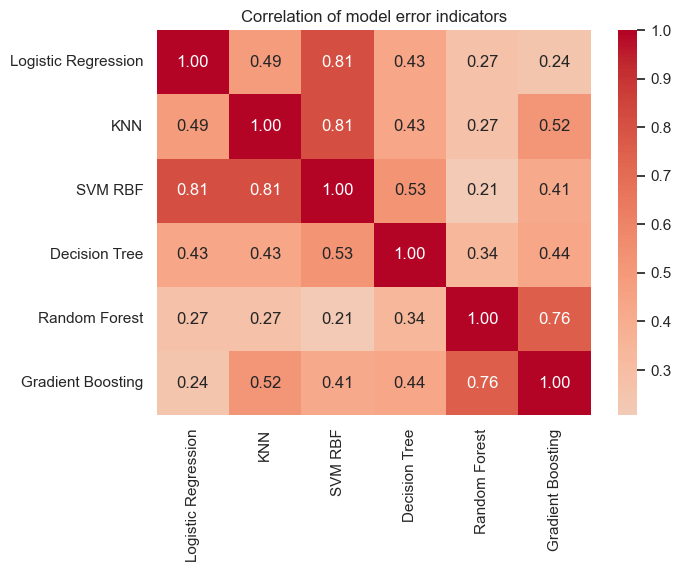

Error counts:


,num_errors
Logistic Regression,2
KNN,2
SVM RBF,3
Random Forest,6
Gradient Boosting,7
Decision Tree,10


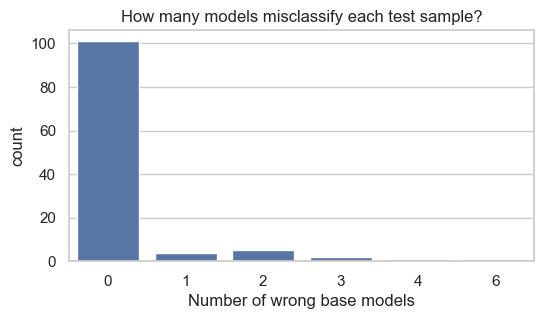

In [7]:
preds = {}
errors = {}
for name, model in base_models.items():
    preds[name] = model.predict(X_test)
    errors[name] = (preds[name] != y_test.values).astype(int)
error_df = pd.DataFrame(errors)
plt.figure(figsize=(7,5))
sns.heatmap(error_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of model error indicators")
plt.show()

print("Error counts:")
display(error_df.sum().sort_values().rename("num_errors").to_frame())

common_error = error_df.sum(axis=1)
plt.figure(figsize=(6,3))
sns.countplot(x=common_error)
plt.title("How many models misclassify each test sample?")
plt.xlabel("Number of wrong base models")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

## Hard Voting Classifier

Hard voting uses majority vote. It does not use confidence/probability information.

Hard voting combines predicted labels by majority rule. It is simple and robust, but it ignores probability confidence. A weak model’s vote counts as much as a strong model’s vote unless weights are manually introduced.

The classification report and confusion matrix break performance into error types. This is more informative than accuracy alone, especially when classes are imbalanced or specific mistakes are more costly.

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



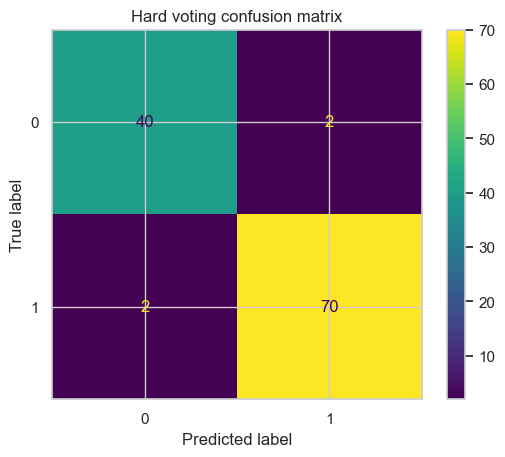

In [8]:
estimators = [(name, clone(model)) for name, model in base_models.items()]
hard_vote = VotingClassifier(estimators=estimators, voting="hard")
hard_vote.fit(X_base, y_base)
hard_pred = hard_vote.predict(X_test)
print(classification_report(y_test, hard_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, hard_pred)
plt.title("Hard voting confusion matrix")
plt.show()

### Analytical interpretation

The confusion matrix and report identify which class or error type drives the score. For imbalanced data, recall and precision for the positive/minority class are more informative than accuracy alone.

## Soft Voting Classifier

Soft voting combines predicted probabilities rather than class labels. This is useful when base models provide reliable confidence estimates.

Soft voting averages predicted probabilities. It can outperform hard voting when probabilities are meaningful, but poorly calibrated probabilities can distort the average and hurt performance.

{'Accuracy': 0.956140350877193, 'Precision': 0.971830985915493, 'Recall': 0.9583333333333334, 'F1': 0.965034965034965, 'ROC_AUC': 0.9930555555555556, 'PR_AUC': 0.9957713026608682}


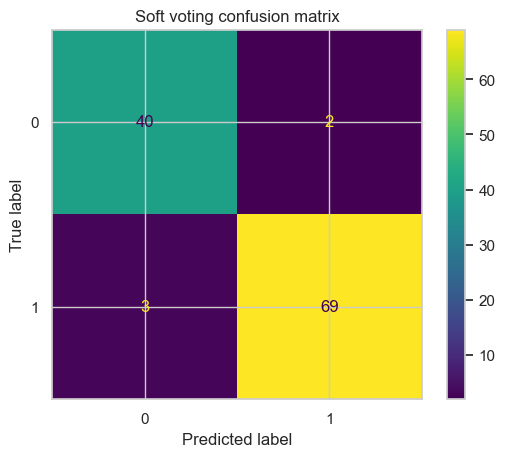

Weights: {'Logistic Regression': 0.17, 'KNN': 0.166, 'SVM RBF': 0.169, 'Decision Tree': 0.163, 'Random Forest': 0.165, 'Gradient Boosting': 0.167}
{'Accuracy': 0.9649122807017544, 'Precision': 0.9722222222222222, 'Recall': 0.9722222222222222, 'F1': 0.9722222222222222, 'ROC_AUC': 0.9930555555555556, 'PR_AUC': 0.9957713026608682}


In [9]:
soft_vote = VotingClassifier(estimators=estimators, voting="soft")
soft_vote.fit(X_base, y_base)
soft_score = soft_vote.predict_proba(X_test)[:,1]
soft_pred = (soft_score >= 0.5).astype(int)
print(binary_metrics(y_test, soft_pred, soft_score))
ConfusionMatrixDisplay.from_predictions(y_test, soft_pred)
plt.title("Soft voting confusion matrix")
plt.show()

# Manual weights based on validation F1, normalized.
val_f1 = []
for name, model in base_models.items():
    val_pred = model.predict(X_blend)
    val_f1.append(max(f1_score(y_blend, val_pred), 1e-6))
weights = np.array(val_f1) / np.sum(val_f1)
weighted_soft = VotingClassifier(estimators=estimators, voting="soft", weights=weights)
weighted_soft.fit(X_base, y_base)
w_score = weighted_soft.predict_proba(X_test)[:,1]
w_pred = (w_score >= 0.5).astype(int)
print("Weights:", dict(zip(base_models.keys(), weights.round(3))))
print(binary_metrics(y_test, w_pred, w_score))

### Analytical interpretation

Soft voting should be judged together with probability calibration. If one model is overconfident, it can dominate the probability average even when its class labels are not consistently better.

## Manual probability averaging

This makes soft voting transparent. It also allows comparing equal weighting with validation-informed weighting.

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

In [10]:
# Refit base models on base split and collect probability predictions
prob_test = []
prob_blend = []
model_names = []
for name, model in base_models.items():
    fitted = clone(model).fit(X_base, y_base)
    if hasattr(fitted, "predict_proba"):
        prob_test.append(fitted.predict_proba(X_test)[:,1])
        prob_blend.append(fitted.predict_proba(X_blend)[:,1])
        model_names.append(name)
prob_test = np.column_stack(prob_test)
prob_blend = np.column_stack(prob_blend)

equal_avg = prob_test.mean(axis=1)
equal_pred = (equal_avg >= 0.5).astype(int)
print("Equal probability average:", binary_metrics(y_test, equal_pred, equal_avg))

# Validation-informed weights using F1 from blend set for probability-producing models
blend_weights=[]
for j, name in enumerate(model_names):
    pred_blend=(prob_blend[:,j] >= 0.5).astype(int)
    blend_weights.append(max(f1_score(y_blend, pred_blend), 1e-6))
blend_weights=np.array(blend_weights)/np.sum(blend_weights)
weighted_avg = prob_test @ blend_weights
weighted_pred=(weighted_avg >= 0.5).astype(int)
print("Model names:", model_names)
print("Blend weights:", blend_weights.round(3))
print("Weighted probability average:", binary_metrics(y_test, weighted_pred, weighted_avg))

Equal probability average: {'Accuracy': 0.956140350877193, 'Precision': 0.971830985915493, 'Recall': 0.9583333333333334, 'F1': 0.965034965034965, 'ROC_AUC': 0.9930555555555556, 'PR_AUC': 0.9957713026608682}
Model names: ['Logistic Regression', 'KNN', 'SVM RBF', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Blend weights: [0.17  0.166 0.169 0.163 0.165 0.167]
Weighted probability average: {'Accuracy': 0.9649122807017544, 'Precision': 0.9722222222222222, 'Recall': 0.9722222222222222, 'F1': 0.9722222222222222, 'ROC_AUC': 0.9930555555555556, 'PR_AUC': 0.9957713026608682}


### Analytical interpretation

Stacking improves only if the meta-learner receives complementary information from base models. If the score is similar to the best individual model, the ensemble may still be useful for stability, but the added complexity should be justified.

## Blending with a hold-out validation set

Blending trains base models on `X_base`, creates predictions on `X_blend`, and trains a meta-model on those validation predictions. It is simple, but base models use less training data.

The learned coefficients are organized by magnitude. This gives an interpretable view of which standardized variables most strongly influence the linear prediction.

In [11]:
# Build blend features from base-model predicted probabilities on X_blend
blend_features = []
test_features = []
blend_feature_names = []
for name, model in base_models.items():
    fitted = clone(model).fit(X_base, y_base)
    if hasattr(fitted, "predict_proba"):
        blend_features.append(fitted.predict_proba(X_blend)[:,1])
        test_features.append(fitted.predict_proba(X_test)[:,1])
        blend_feature_names.append(name)
    else:
        blend_features.append(fitted.predict(X_blend))
        test_features.append(fitted.predict(X_test))
        blend_feature_names.append(name)
Z_blend = np.column_stack(blend_features)
Z_test = np.column_stack(test_features)
meta_log = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
meta_log.fit(Z_blend, y_blend)
blend_score = meta_log.predict_proba(Z_test)[:,1]
blend_pred = (blend_score >= 0.5).astype(int)
print(binary_metrics(y_test, blend_pred, blend_score))
coef_df = pd.DataFrame({"base_model": blend_feature_names, "meta_coefficient": meta_log.coef_.ravel()}).sort_values("meta_coefficient", key=abs, ascending=False)
display(coef_df)

{'Accuracy': 0.9649122807017544, 'Precision': 0.9722222222222222, 'Recall': 0.9722222222222222, 'F1': 0.9722222222222222, 'ROC_AUC': 0.9950396825396824, 'PR_AUC': 0.9969614587896921}


,base_model,meta_coefficient
0,Logistic Regression,1.792190
2,SVM RBF,1.658178
1,KNN,1.386383
5,Gradient Boosting,1.044718
4,Random Forest,0.764097
3,Decision Tree,0.593644


### Analytical interpretation

Large standardized coefficients indicate features that strongly influence the linear prediction, but they should not be read as causal effects. Correlated predictors can redistribute coefficient weight, and omitted variables can also distort interpretation.

## Stacking with out-of-fold predictions

`StackingClassifier` creates out-of-fold predictions for training the meta-learner. This reduces leakage compared with training the meta-model on predictions from base models that already saw the same labels.

Stacking is evaluated using out-of-fold predictions so that the meta-learner is trained on predictions produced without direct exposure to the corresponding labels.

{'Accuracy': 0.9736842105263158, 'Precision': 0.9859154929577465, 'Recall': 0.9722222222222222, 'F1': 0.979020979020979, 'ROC_AUC': 0.9957010582010581, 'PR_AUC': 0.9973756574423809}


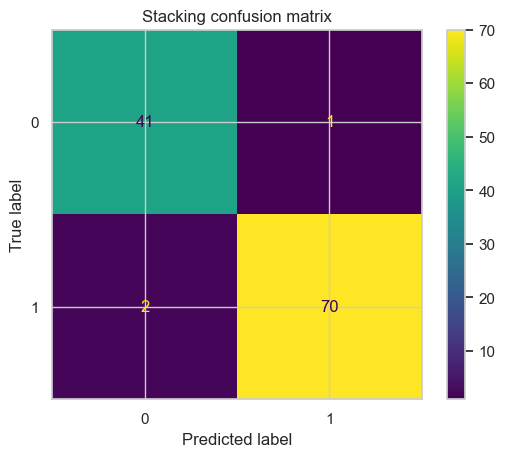

In [12]:
stack_estimators = [(name, clone(model)) for name, model in base_models.items()]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)
# Stacking can use the full training portion because it internally creates out-of-fold predictions.
stack.fit(X_temp, y_temp)
stack_score = stack.predict_proba(X_test)[:,1]
stack_pred = (stack_score >= 0.5).astype(int)
print(binary_metrics(y_test, stack_pred, stack_score))
ConfusionMatrixDisplay.from_predictions(y_test, stack_pred)
plt.title("Stacking confusion matrix")
plt.show()

### Analytical interpretation

Stacking improves only if the meta-learner receives complementary information from base models. If the score is similar to the best individual model, the ensemble may still be useful for stability, but the added complexity should be justified.

## Meta-learner analysis

For a logistic meta-learner, coefficients indicate how meta-features are weighted. High coefficient does not always mean the base model is best alone; complementary behavior can matter.

The learned coefficients are organized by magnitude. This gives an interpretable view of which standardized variables most strongly influence the linear prediction.

In [13]:
try:
    final_est = stack.final_estimator_
    names=[]
    for base_name, estimator in stack.named_estimators_.items():
        # Binary predict_proba in stacking may contribute one probability column per estimator depending on sklearn version.
        names.append(base_name)
    coefs = final_est.coef_.ravel()
    display(pd.DataFrame({"meta_feature_index": range(len(coefs)), "coefficient": coefs}).sort_values("coefficient", key=abs, ascending=False))
except Exception as e:
    print("Meta coefficient display skipped:", e)

,meta_feature_index,coefficient
0,0,2.626771
2,2,2.041040
1,1,1.434989
5,5,1.304412
4,4,1.207625
3,3,0.137005


### Analytical interpretation

Stacking improves only if the meta-learner receives complementary information from base models. If the score is similar to the best individual model, the ensemble may still be useful for stability, but the added complexity should be justified.

## Hyperparameter reasoning in ensembles

Instead of brute-force searching, compare analytically selected ensemble variants: remove weak models, remove highly correlated models, and compare simple vs complex meta-learners.

Soft voting combines predicted probabilities rather than class labels. This is useful when base models provide reliable confidence estimates.

In [14]:
variant_sets = {
    "All models": list(base_models.keys()),
    "No decision tree": [m for m in base_models if m != "Decision Tree"],
    "Top validation models": base_df.head(4)["Model"].tolist(),
    "Diverse compact": ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"],
}
variant_rows=[]
for label, names in variant_sets.items():
    est=[(name, clone(base_models[name])) for name in names]
    voter=VotingClassifier(estimators=est, voting="soft")
    voter.fit(X_base, y_base)
    score=voter.predict_proba(X_test)[:,1]
    pred=(score>=0.5).astype(int)
    row={"Ensemble": label, "num_models": len(names)}
    row.update(binary_metrics(y_test, pred, score))
    variant_rows.append(row)
variant_df=pd.DataFrame(variant_rows).sort_values("F1", ascending=False)
display(variant_df)

,Ensemble,num_models,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Top validation models,4,0.973684,0.972603,0.986111,0.979310,0.996032,0.997596
1,No decision tree,5,0.964912,0.972222,0.972222,0.972222,0.994378,0.996647
0,All models,6,0.956140,0.971831,0.958333,0.965035,0.993056,0.995771
3,Diverse compact,4,0.947368,0.945946,0.972222,0.958904,0.994048,0.996470


### Analytical interpretation

Soft voting should be judged together with probability calibration. If one model is overconfident, it can dominate the probability average even when its class labels are not consistently better.

## Final comparison

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

In [15]:
comparison_rows=[]
# individual models already trained/evaluated earlier on X_base -> X_test
for _, row in base_df.iterrows():
    comparison_rows.append({"System": row["Model"], "Type": "Individual", **{k: row[k] for k in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]}})

systems = {
    "Hard Voting": (hard_pred, None),
    "Soft Voting": (soft_pred, soft_score),
    "Weighted Soft Voting": (w_pred, w_score),
    "Probability Averaging": (equal_pred, equal_avg),
    "Blending": (blend_pred, blend_score),
    "Stacking": (stack_pred, stack_score),
}
for name, (pred, score) in systems.items():
    row={"System": name, "Type": "Ensemble"}
    row.update(binary_metrics(y_test, pred, score))
    comparison_rows.append(row)
comparison=pd.DataFrame(comparison_rows).sort_values("F1", ascending=False)
display(comparison)

,System,Type,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,KNN,Individual,0.982456,0.972973,1.000000,0.986301,0.991733,0.993475
1,Logistic Regression,Individual,0.982456,0.986111,0.986111,0.986111,0.995040,0.996880
2,SVM RBF,Individual,0.973684,0.972603,0.986111,0.979310,0.994378,0.996585
11,Stacking,Ensemble,0.973684,0.985915,0.972222,0.979021,0.995701,0.997376
6,Hard Voting,Ensemble,0.964912,0.972222,0.972222,0.972222,NaN,NaN
8,Weighted Soft Voting,Ensemble,0.964912,0.972222,0.972222,0.972222,0.993056,0.995771
10,Blending,Ensemble,0.964912,0.972222,0.972222,0.972222,0.995040,0.996961
7,Soft Voting,Ensemble,0.956140,0.971831,0.958333,0.965035,0.993056,0.995771
9,Probability Averaging,Ensemble,0.956140,0.971831,0.958333,0.965035,0.993056,0.995771
3,Random Forest,Individual,0.947368,0.958333,0.958333,0.958333,0.991733,0.995124


### Analytical interpretation

Stacking improves only if the meta-learner receives complementary information from base models. If the score is similar to the best individual model, the ensemble may still be useful for stability, but the added complexity should be justified.

## Error analysis: best individual vs best ensemble

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

In [16]:
best_ind_name = base_df.iloc[0]["Model"]
best_ind_pred = preds[best_ind_name]
best_ens_name = comparison[comparison["Type"]=="Ensemble"].iloc[0]["System"]
best_ens_pred = systems[best_ens_name][0]
err = pd.DataFrame({
    "true": y_test.values,
    "best_individual_pred": best_ind_pred,
    "best_ensemble_pred": best_ens_pred,
})
err["individual_wrong"] = err["best_individual_pred"] != err["true"]
err["ensemble_wrong"] = err["best_ensemble_pred"] != err["true"]
print("Best individual:", best_ind_name)
print("Best ensemble:", best_ens_name)
print("Individual errors:", err["individual_wrong"].sum())
print("Ensemble errors:", err["ensemble_wrong"].sum())
print("Errors corrected by ensemble:", (err["individual_wrong"] & ~err["ensemble_wrong"]).sum())
print("New errors introduced by ensemble:", (~err["individual_wrong"] & err["ensemble_wrong"]).sum())
display(err[err["individual_wrong"] | err["ensemble_wrong"]].head(15))

Best individual: KNN
Best ensemble: Stacking
Individual errors: 2
Ensemble errors: 3
Errors corrected by ensemble: 1
New errors introduced by ensemble: 2


,true,best_individual_pred,best_ensemble_pred,individual_wrong,ensemble_wrong
3,1,1,0,False,True
16,1,1,0,False,True
53,0,1,1,True,True
84,0,1,0,True,False


### Analytical interpretation

The corrected-vs-new error table shows that stacking corrected some mistakes but also introduced new ones. This is the right way to judge ensemble value beyond a single aggregate score.

## Additional analytical experiment: calibration before soft voting

Soft voting assumes that model probabilities are comparable. If one model is overconfident, it may dominate the average even when its labels are not better. This experiment compares the Brier score of base-model probabilities.

In [17]:
from sklearn.metrics import brier_score_loss

cal_rows = []
for name, model in base_models.items():
    fitted = clone(model)
    fitted.fit(X_base, y_base)
    if hasattr(fitted, "predict_proba"):
        prob = fitted.predict_proba(X_blend)[:, 1]
        cal_rows.append({
            "Model": name,
            "Blend_Brier_score": brier_score_loss(y_blend, prob),
            "Blend_F1_at_0.5": f1_score(y_blend, (prob >= 0.5).astype(int))
        })
calibration_df = pd.DataFrame(cal_rows).sort_values("Blend_Brier_score")
display(calibration_df)


,Model,Blend_Brier_score,Blend_F1_at_0.5
0,Logistic Regression,0.016378,0.993007
2,SVM RBF,0.018085,0.986111
5,Gradient Boosting,0.030358,0.971831
1,KNN,0.032760,0.965986
4,Random Forest,0.037958,0.965035
3,Decision Tree,0.051586,0.951049


### How to interpret this added experiment
Lower Brier score indicates better probability calibration. A model can have high F1 but poor calibration, which can hurt soft voting or probability averaging. If calibration differs strongly, calibrated classifiers or validation-based weights may be more appropriate.

## Interpretation

Decide whether stacking improved meaningfully or only marginally. A tiny gain may not justify complexity. Strong ensembles usually require diverse base learners with partially different error patterns.

## Limitations

- Stacking can overfit on small data.
- More models increase computation and maintenance complexity.
- Soft voting depends on probability quality.
- Meta-model interpretation is limited.
- Improvement is not guaranteed.

## What we learned

This project covered model diversity, hard voting, soft voting, probability averaging, blending, stacking with out-of-fold predictions, meta-learner interpretation, leakage risk, and ensemble error analysis.

## Possible extensions

Try calibrated stacking, regression stacking, neural-network meta-learners, multi-level stacking, out-of-distribution robustness tests, and ensemble uncertainty estimation.